In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("creditcard.csv")



In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
# Reduce size while keeping fraud-to-non-fraud ratio
df_sample = df.groupby("Class", group_keys=False).apply(lambda x: x.sample(frac=0.1))

<ipython-input-5-00fd5dfb6453>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby("Class", group_keys=False).apply(lambda x: x.sample(frac=0.1))


In [ ]:
# Save the reduced dataset
df_sample.to_csv("creditcard_sample.csv", index=False)

In [ ]:
# Display the new dataset size
print(f"Original Size: {df.shape[0]} rows, Reduced Size: {df_sample.shape[0]} rows")

Original Size: 144667 rows, Reduced Size: 14467 rows


In [ ]:
from google.colab import files
df_sample.to_csv("creditcard_sample.csv", index=False)
files.download("creditcard_sample.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df_sample.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
104170,68942,-2.571205,-1.462427,0.842254,2.926177,1.862311,-0.812764,-0.774004,0.662782,-1.080069,...,0.126416,-0.767521,0.016032,-0.672656,-0.214740,-0.083846,0.028386,-0.325302,75.66,0.0
121095,76069,-4.617040,4.878306,-1.538037,-0.203192,-0.497997,-1.540599,1.329970,-0.425306,3.601052,...,-0.767371,0.643327,0.089791,0.679048,0.011394,-0.714068,-0.553538,-1.945358,1.79,0.0
88665,62236,1.551405,-0.988558,0.130634,-1.637892,-1.081491,-0.236575,-1.038522,-0.051261,-2.052915,...,-0.221775,-0.254938,-0.072902,-0.519574,0.471808,-0.171550,0.026964,0.000972,5.00,0.0
23917,32982,1.100795,-0.256195,0.936157,0.907995,-0.956729,-0.387047,-0.379390,-0.029833,0.763302,...,0.095510,0.404238,-0.153167,0.478845,0.484401,0.503032,-0.002868,0.028775,59.90,0.0
29241,35374,0.902198,-0.888158,0.802006,-0.633431,-1.053741,0.218798,-0.557278,0.233346,1.728441,...,-0.006749,0.098209,-0.122230,0.066354,0.420844,-0.731944,0.091328,0.042125,127.11,0.0


In [ ]:
class_counts = df_sample['Class'].value_counts()
print("\nClass Distribution:")
print(class_counts)


Class Distribution:
Class
0.0    14439
1.0       28
Name: count, dtype: int64


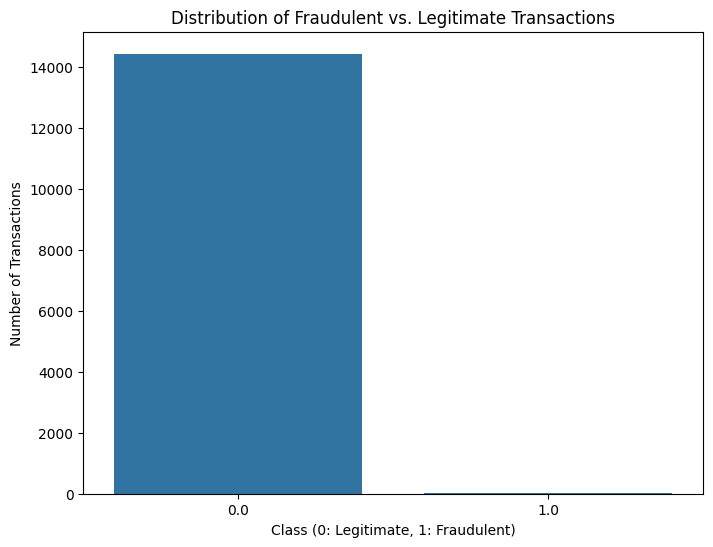

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df_sample)
plt.title('Distribution of Fraudulent vs. Legitimate Transactions')
plt.xlabel('Class (0: Legitimate, 1: Fraudulent)')
plt.ylabel('Number of Transactions')
plt.show()

In [ ]:
#Calculate percentages of fraudulent and legitimate transactions
fraud_percentage = df_sample['Class'].value_counts(normalize=True) * 100
print("\nPercentage of Fraudulent and Legitimate Transactions:")
print(fraud_percentage)


Percentage of Fraudulent and Legitimate Transactions:
Class
0.0    99.806456
1.0     0.193544
Name: proportion, dtype: float64


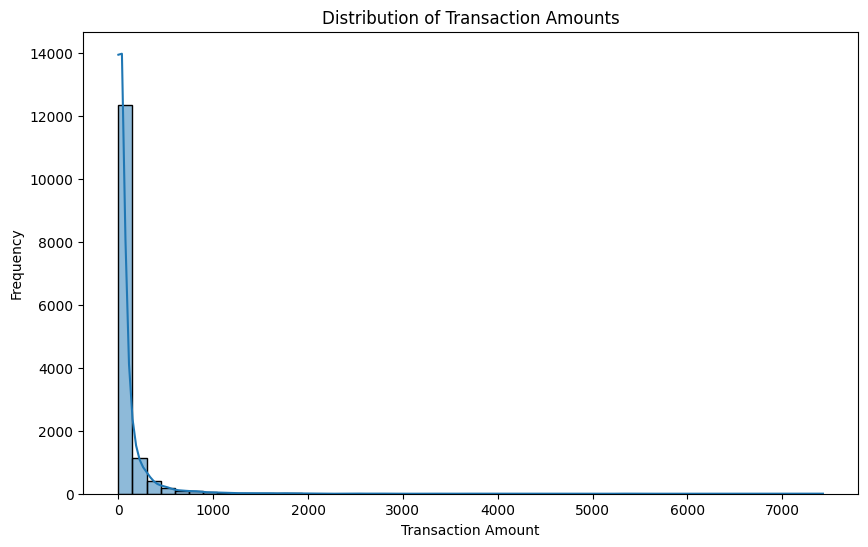

In [ ]:
# 4. Transaction Amount Distribution - This section visualizes the distribution of transaction amounts to identify any patterns.

# Plot the distribution of transaction amounts
plt.figure(figsize=(10, 6))
sns.histplot(x=df_sample['Amount'], kde=True, bins=50)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()


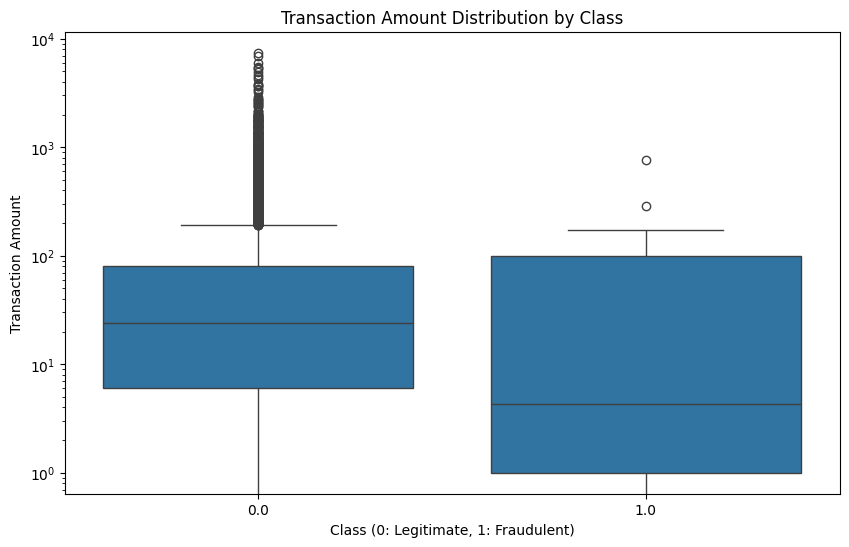

In [ ]:
# Plot transaction amounts by class using box plots
plt.figure(figsize=(10, 6))
sns.boxplot(x='Class', y='Amount', data=df_sample)
plt.title('Transaction Amount Distribution by Class')
plt.xlabel('Class (0: Legitimate, 1: Fraudulent)')
plt.ylabel('Transaction Amount')
plt.yscale('log')  # Using log scale to handle outliers
plt.show()

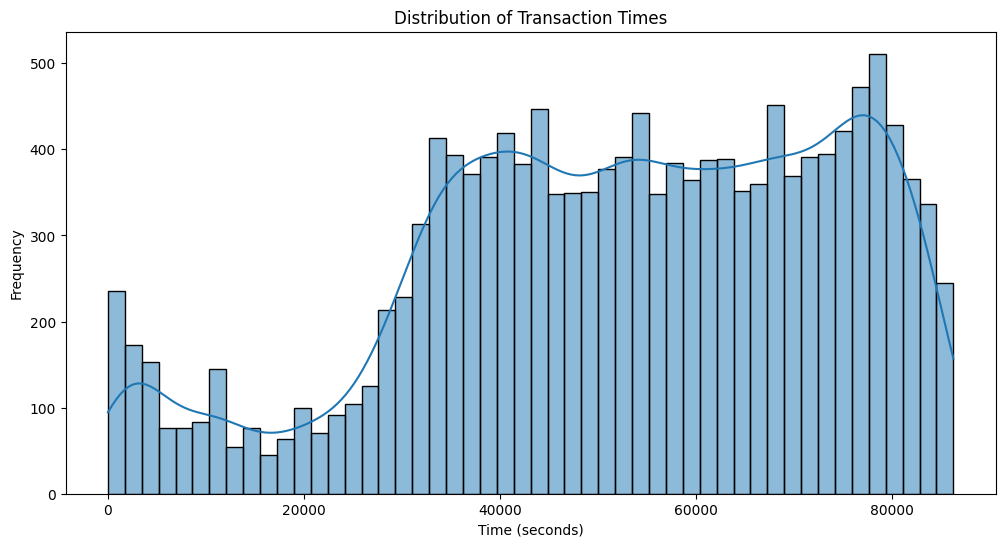

In [ ]:
# 5. Time-Based Trends - This section examines transaction frequency over time.

# Plot the distribution of transaction times

plt.figure(figsize=(12, 6))
sns.histplot(x=df_sample['Time'], kde=True, bins=50)
plt.title('Distribution of Transaction Times')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.show()

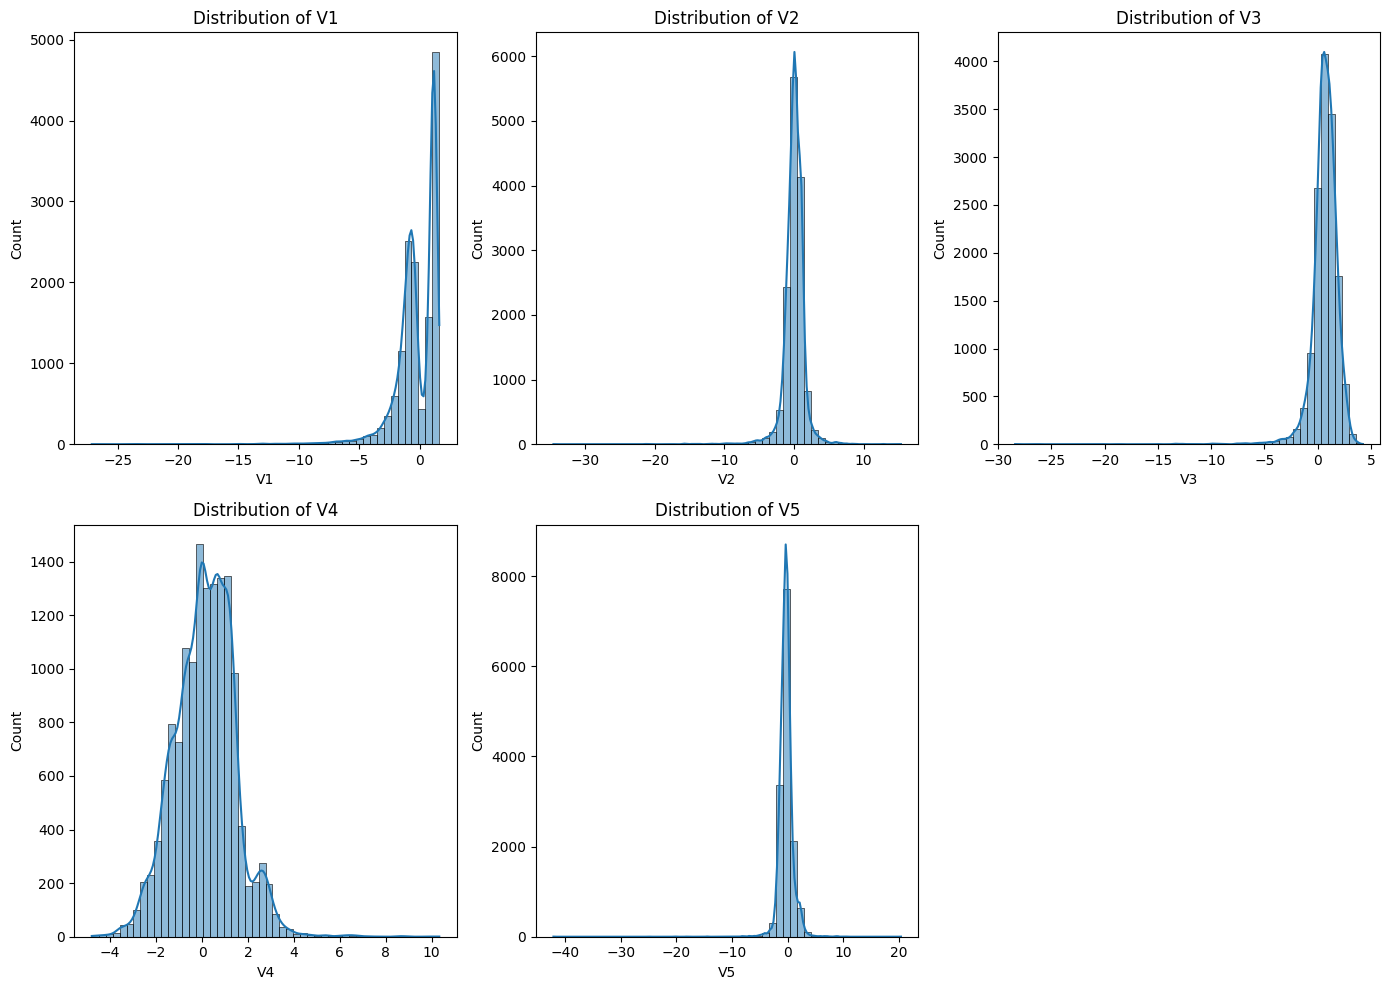

In [ ]:
# 6. PCA Features Analysis - This section explores the distribution of PCA-transformed features.

# Select a subset of PCA features for demonstration
pca_features = ['V1', 'V2', 'V3', 'V4', 'V5']

# Plot histograms of the selected PCA features
plt.figure(figsize=(14, 10))
for i, feature in enumerate(pca_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(x=df_sample[feature], kde=True, bins=50)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

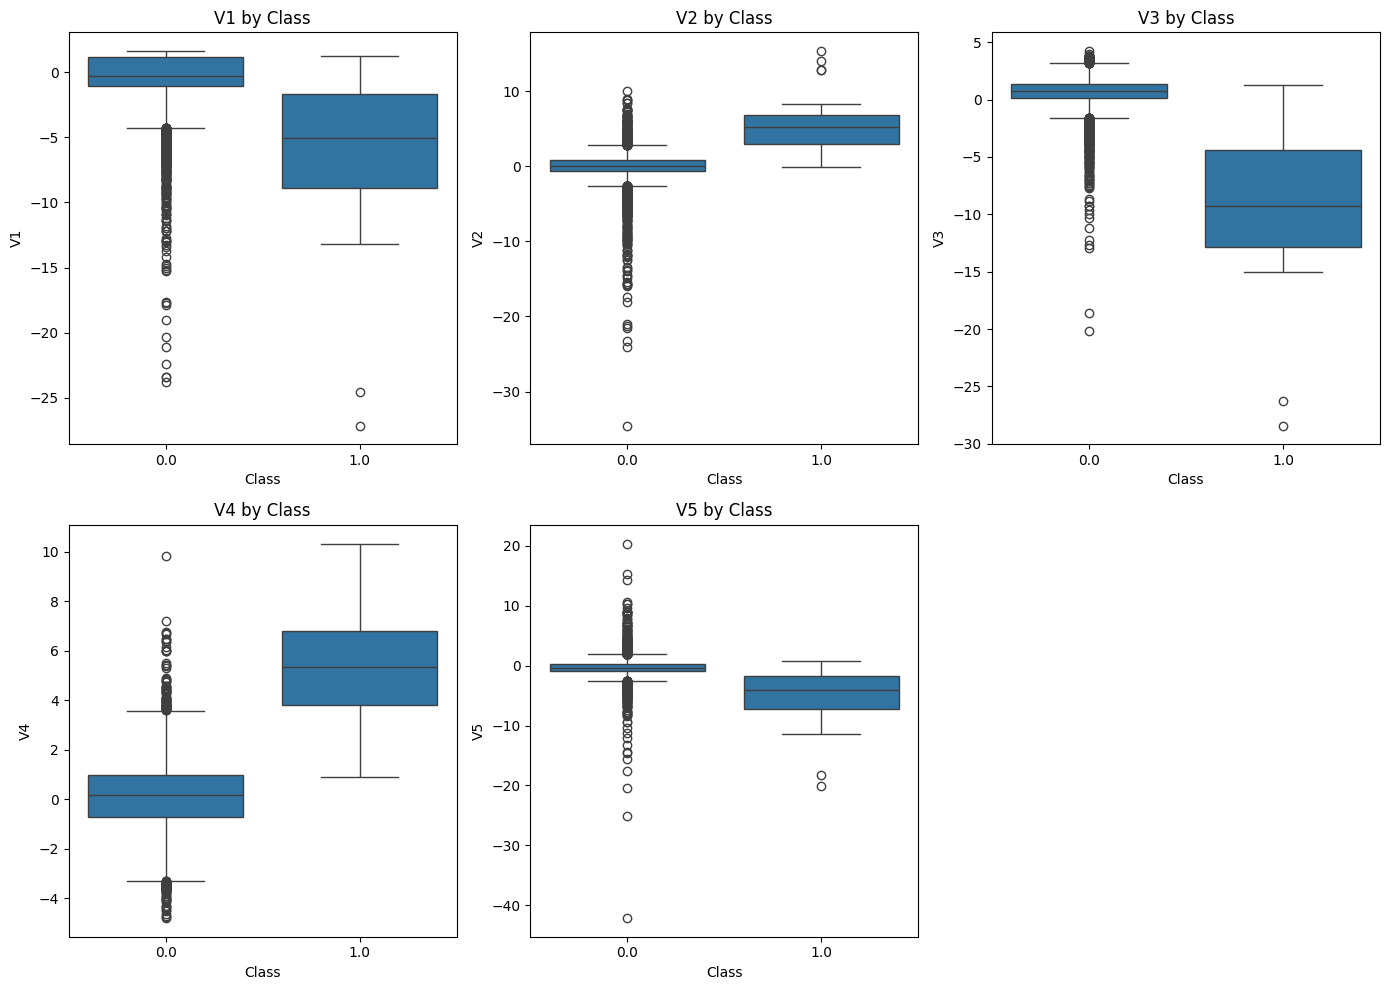

In [ ]:
# Plot box plots of PCA features by class

plt.figure(figsize=(14, 10))
for i, feature in enumerate(pca_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='Class', y=df_sample[feature], data=df_sample)
    plt.title(f'{feature} by Class')
plt.tight_layout()
plt.show()

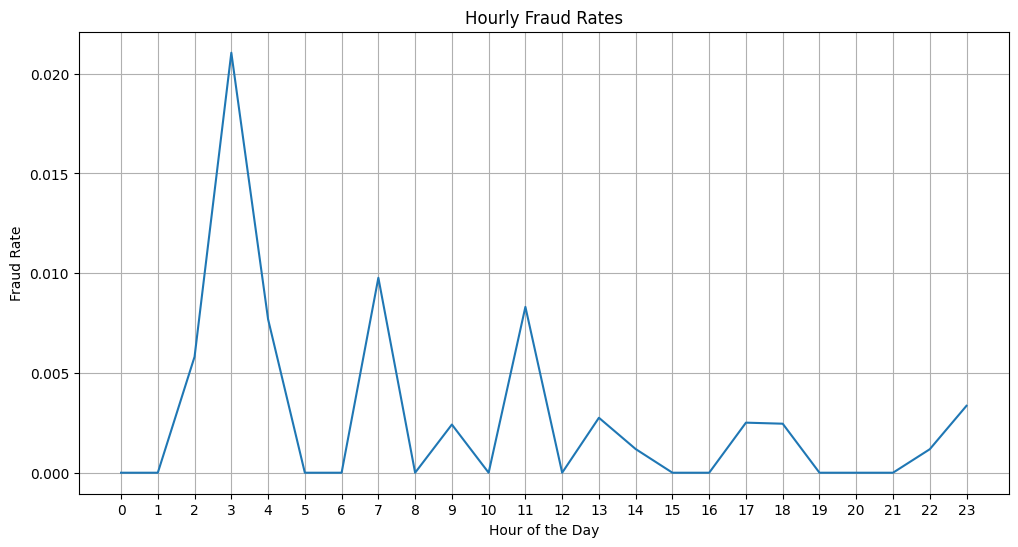

    Hour     Class
0      0  0.000000
1      1  0.000000
2      2  0.005814
3      3  0.021053
4      4  0.007692
5      5  0.000000
6      6  0.000000
7      7  0.009772
8      8  0.000000
9      9  0.002415
10    10  0.000000
11    11  0.008314
12    12  0.000000
13    13  0.002755
14    14  0.001186
15    15  0.000000
16    16  0.000000
17    17  0.002509
18    18  0.002457
19    19  0.000000
20    20  0.000000
21    21  0.000000
22    22  0.001176
23    23  0.003356


In [ ]:
# 7. Detailed Fraud rate calculation"""

df_sample['Hour'] = df_sample['Time'].apply(lambda x: int(x/3600))

hourly_fraud_rates = df_sample.groupby('Hour')['Class'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(x='Hour', y='Class', data=hourly_fraud_rates)
plt.title('Hourly Fraud Rates')
plt.xlabel('Hour of the Day')
plt.ylabel('Fraud Rate')
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

print(hourly_fraud_rates)

In [ ]:
# Check for missing values
print("\nMissing values before handling:")
print(df_sample.isnull().sum())


Missing values before handling:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
Hour      0
dtype: int64


In [ ]:
# Handle missing values (if any) by filling with the mean
# For demonstration, we'll fill with the mean.  Adapt this as needed.
df_sample = df_sample.fillna(df_sample.mean())


print("\nMissing values after handling:")
print(df_sample.isnull().sum())


Missing values after handling:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
Hour      0
dtype: int64


In [ ]:
# Function to detect outliers using the IQR method
def detect_outliers_iqr(data, column, threshold=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

In [ ]:
# Function to cap outliers using Winsorization
def cap_outliers_winsorize(data, column, lower_percentile=0.05, upper_percentile=0.95):
    lower_bound = data[column].quantile(lower_percentile)
    upper_bound = data[column].quantile(upper_percentile)
    data[column] = data[column].clip(lower_bound, upper_bound)
    return data

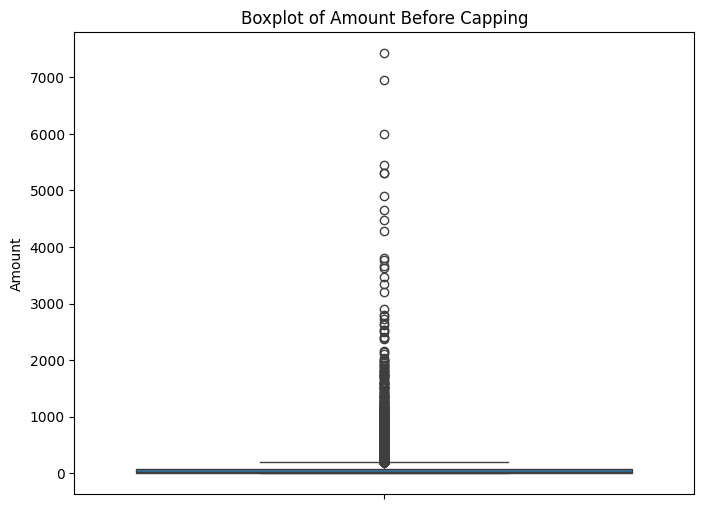

Number of outliers before capping: 1615
Summary statistics before capping:
 count    14467.000000
mean        91.148958
std        252.367376
min          0.000000
25%          5.990000
50%         23.970000
75%         80.875000
max       7429.150000
Name: Amount, dtype: float64


In [ ]:
# Before capping
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_sample['Amount'])
plt.title("Boxplot of Amount Before Capping")
plt.show()

outliers_amount = detect_outliers_iqr(df_sample, 'Amount')
print("Number of outliers before capping:", len(outliers_amount))
print("Summary statistics before capping:\n", df_sample['Amount'].describe())

In [ ]:
#Cap outliers
df_sample = cap_outliers_winsorize(df_sample, 'Amount')

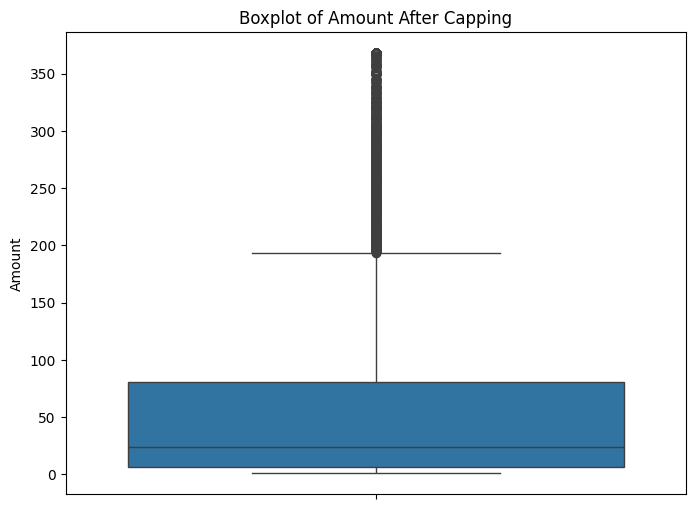

In [ ]:
# After capping
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_sample['Amount'])
plt.title("Boxplot of Amount After Capping")
plt.show()

In [ ]:
outliers_amount = detect_outliers_iqr(df_sample, 'Amount')
print("Number of outliers after capping:", len(outliers_amount))
print("Summary statistics after capping:\n", df_sample['Amount'].describe())

Number of outliers after capping: 1615
Summary statistics after capping:
 count    14467.000000
mean        67.467049
std         98.051288
min          0.990000
25%          5.990000
50%         23.970000
75%         80.875000
max        368.000000
Name: Amount, dtype: float64


In [ ]:
# Function to perform outlier analysis and Winsorization
def analyze_and_cap_outliers(df, column, iqr_threshold=1.5, lower_percentile=0.05, upper_percentile=0.95):
    print(f"\nAnalyzing outliers in '{column}' column:")

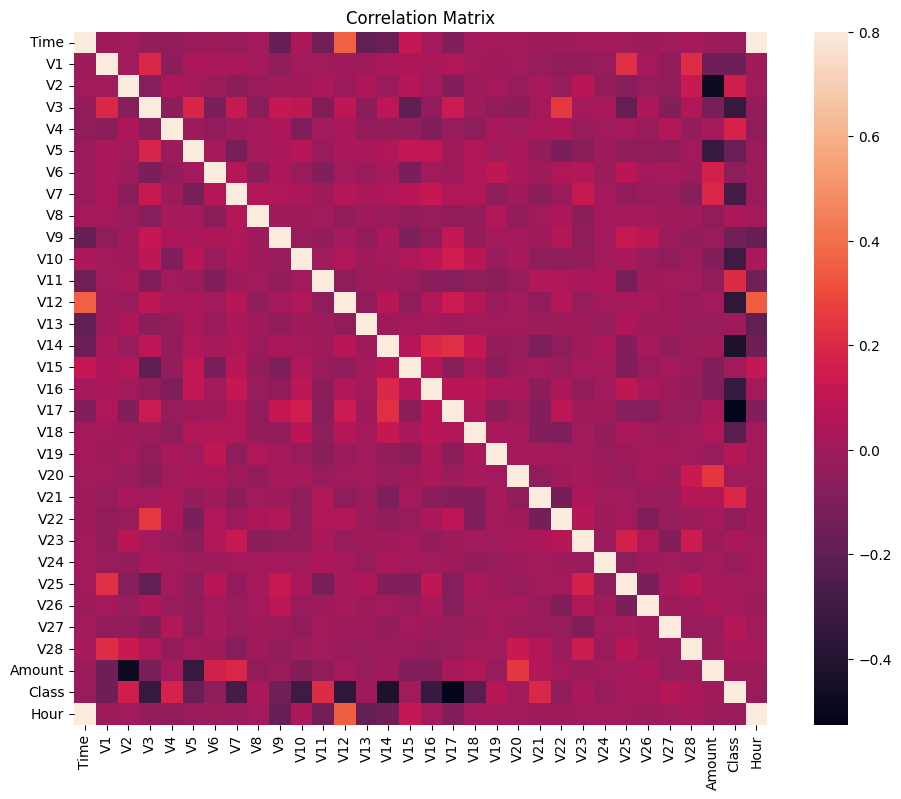

In [ ]:
 #Correlation Matrix ---
corr_matrix = df_sample.corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, vmax=.8, square=True)
plt.title('Correlation Matrix')
plt.show()

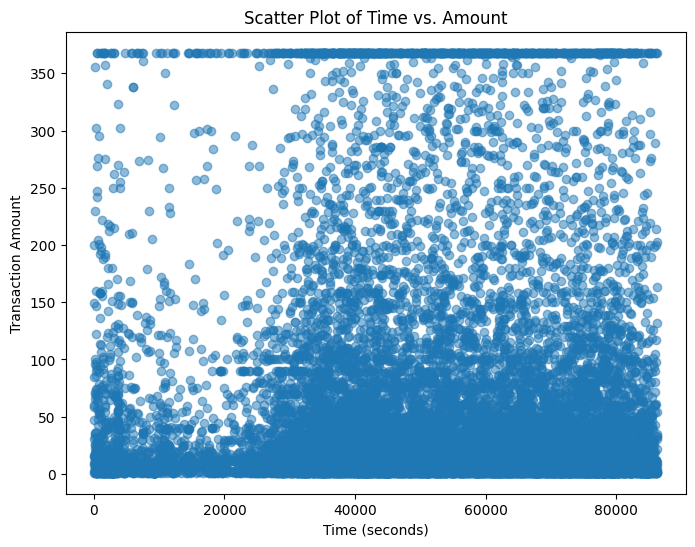

In [ ]:
# Scatter Plot (Example) ---
plt.figure(figsize=(8, 6))
plt.scatter(df_sample['Time'], df_sample['Amount'], alpha=0.5)
plt.title('Scatter Plot of Time vs. Amount')
plt.xlabel('Time (seconds)')
plt.ylabel('Transaction Amount')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 2. Data Preprocessing
# Separate features (X) and target (y)
X = df_sample.drop('Class', axis=1)
y = df_sample['Class']

In [ ]:
# Scale 'Time' and 'Amount'
scaler = StandardScaler()
X['Time'] = scaler.fit_transform(X[['Time']])
X['Amount'] = scaler.fit_transform(X[['Amount']])

In [ ]:
# 3. Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [ ]:
import numpy as np

In [ ]:
# 4. Model Training (Random Forest with Class Weighting)
# Calculate class weights
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced',
                                                 classes=np.unique(y_train),
                                                 y=y_train)
class_weights = {0: class_weights[0], 1: class_weights[1]}

# Initialize and train the Random Forest model
model = RandomForestClassifier(n_estimators=100, # You can adjust the number of trees
                             random_state=42,
                             class_weight=class_weights)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 0.5009696186166774,
                                     1: 258.3333333333333},
                       random_state=42)

In [ ]:
# 5. Model Evaluation
# Make predictions on the test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class (fraud)

In [ ]:
# Print classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3610
         1.0       0.75      0.86      0.80         7

    accuracy                           1.00      3617
   macro avg       0.87      0.93      0.90      3617
weighted avg       1.00      1.00      1.00      3617



In [ ]:
# Calculate and print ROC AUC score
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.9995647012267511


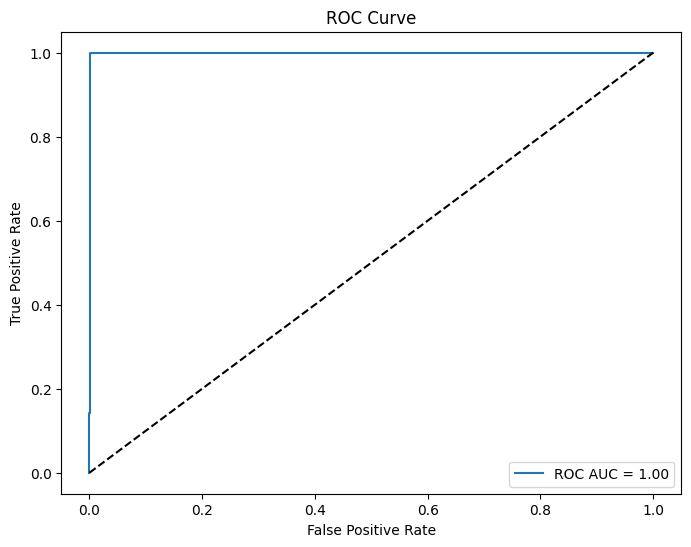

In [ ]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line representing random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
# 6. Feature Importance
feature_importances = model.feature_importances_
feature_names = X.columns

In [ ]:
# Sort features by importance
indices = np.argsort(feature_importances)[::-1]


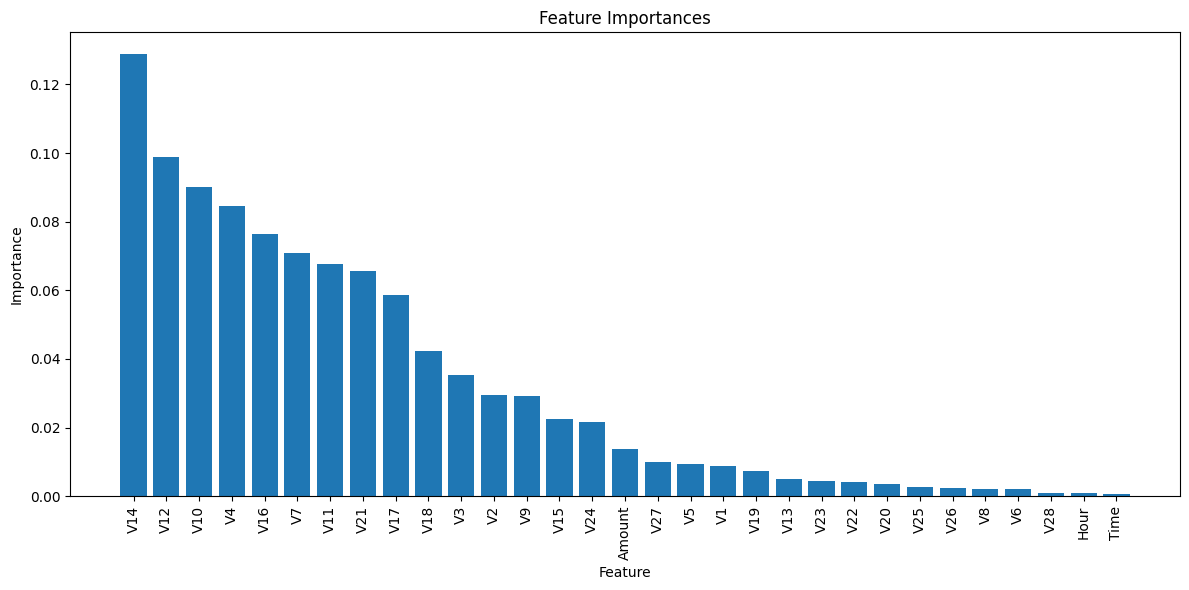

In [ ]:
# Plot feature importances
plt.figure(figsize=(12, 6))
plt.bar(range(X.shape[1]), feature_importances[indices], align='center')
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.title('Feature Importances')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 3. Data Splitting
# Isolation Forest is typically used for unsupervised anomaly detection
# Here, we'll train it on the majority class (non-fraudulent transactions)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [ ]:
# Train on non-fraudulent data
X_train_non_fraud = X_train[y_train == 0]

In [ ]:
# 4. Model Training (Isolation Forest)
model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42) # Adjust contamination as needed
model.fit(X_train_non_fraud)

IsolationForest(contamination=0.01, random_state=42)

In [ ]:
# 5. Anomaly Detection and Evaluation
# Predict anomalies on the test set
y_pred = model.predict(X_test)

In [ ]:
# Convert predictions to 0 and 1 (1 for anomaly, 0 for normal)
y_pred[y_pred == 1] = 0
y_pred[y_pred == -1] = 1

In [ ]:
# Print classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      3610
         1.0       0.12      0.86      0.21         7

    accuracy                           0.99      3617
   macro avg       0.56      0.92      0.60      3617
weighted avg       1.00      0.99      0.99      3617



In [ ]:
# Calculate and print ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred)
print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.9226157499010684


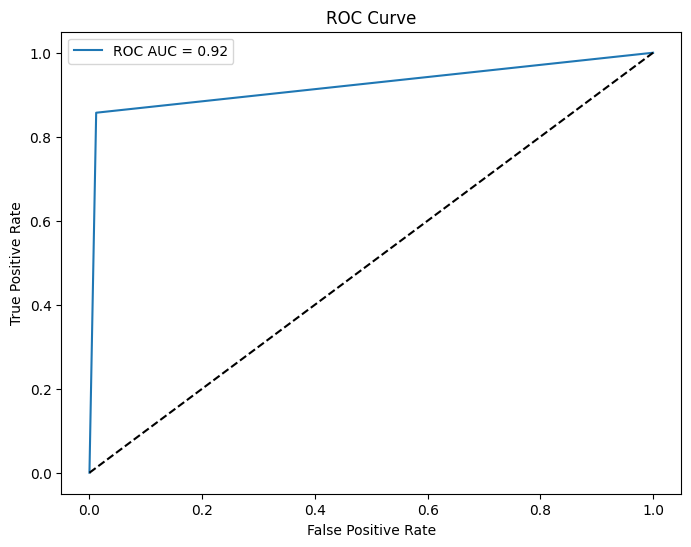

In [ ]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line representing random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()